# CNM Analysis for d+Au RHIC 200 GeV **with Nuclear Absorption**

**NEW**: This notebook includes nuclear absorption effects (σ_abs = 4.2 mb from Vogt 2004).

Two additional components:
- **`npdf_abs`**: nPDF shadowing + nuclear absorption
- **`cnm_abs`**: Full CNM + nuclear absorption

All original components remain for comparison.


## Setup & Calc

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dataclasses import replace

sys.path.append('..')
sys.path.append('../eloss_code')
sys.path.append('../cnm_combine')
sys.path.append('../npdf_code')

from cnm_combine_fast_nuclabs import CNMCombineFast
from particle import Particle
from system_configs import RHICConfig as Config
from npdf_nuclAbs_centrality_dAu import NuclearAbsorption

import warnings
warnings.filterwarnings('ignore')

SAVE_PDF = True
SAVE_CSV = True
DPI = 150
ALPHA_BAND = 0.25
STEP_DEFAULT = True

SIGMA_ABS_CENTRAL = 4.2
SIGMA_ABS_LOW = 3.0
SIGMA_ABS_HIGH = 5.5
ABS_MODE = 'dA_avg_TA'

COLORS = {
    'abs_only': 'tab:green',
    'npdf': '#E69F00',
    'eloss': "#EC5B5B",
    'broad': "#2B2BEF",
    'eloss_broad': "#020202",
    'cnm': 'gray',
    'cnm_abs': '#7B2CBF',
}

COMP_LABELS = {
    'abs_only': 'Absorption Only',
    'npdf': 'nPDF (EPPS21)',
    'eloss': 'Energy Loss',
    'broad': r'$p_T$ Broadening',
    'eloss_broad': r'ELoss + $p_T$ Broad',
    'cnm': 'Total CNM',
    'cnm_abs': 'CNM + Abs',
}

print("Setup complete.")


Setup complete.


In [2]:
def step_from_centers(xc, yc):
    xc = np.asarray(xc, float)
    yc = np.asarray(yc, float)
    if xc.size < 2:
        dx = 1.0
        return np.array([xc[0]-0.5*dx, xc[0]+0.5*dx], float), np.array([yc[0], yc[0]], float)
    dx = xc[1] - xc[0]
    edges = np.concatenate([xc - 0.5*dx, [xc[-1] + 0.5*dx]])
    vals = np.concatenate([yc, [yc[-1]]])
    return edges, vals

def apply_pub_style(ax, xlim, ylim, xlabel, ylabel, tag=None, note=None):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.axhline(1.0, color='k', ls='-', lw=0.8, alpha=0.5)
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=10)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    if tag:
        ax.text(0.95, 0.95, tag, transform=ax.transAxes, ha='right', va='top', fontsize=12, fontweight='bold')
    if note:
        ax.text(0.05, 0.05, note, transform=ax.transAxes, ha='left', va='bottom', fontsize=10,
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

def plot_component_band(ax, x_cent, bands, comp, tag, step=True):
    Rc_dict, Rlo_dict, Rhi_dict = bands[comp]
    xc = np.asarray(x_cent)
    yc = np.asarray(Rc_dict[tag])
    yl = np.asarray(Rlo_dict[tag])
    yh = np.asarray(Rhi_dict[tag])
    yl2 = np.minimum(yl, yh)
    yh2 = np.maximum(yl, yh)
    yl2 = np.minimum(yl2, yc)
    yh2 = np.maximum(yh2, yc)
    color = COLORS.get(comp, 'black')
    label = COMP_LABELS.get(comp, comp)
    if step:
        xe, ye = step_from_centers(xc, yc)
        _, yel = step_from_centers(xc, yl2)
        _, yeh = step_from_centers(xc, yh2)
        ax.step(xe, ye, where='post', color=color, lw=1.7, label=label)
        ax.fill_between(xe, yel, yeh, step='post', color=color, alpha=ALPHA_BAND, lw=0)
    else:
        ax.plot(xc, yc, color=color, lw=1.7, label=label)
        ax.fill_between(xc, yl2, yh2, color=color, alpha=ALPHA_BAND, lw=0)

# absorption helpers

def ncoll_by_cent_bins(gl, cent_bins):
    kind = "dA" if getattr(gl.spec, "system", "dA") == "dA" else "pA"
    fn = gl.ncoll_mean_bin_dA_optical if kind == "dA" else gl.ncoll_mean_bin_pA_optical
    ncoll = [fn(a/100.0, b/100.0) for (a,b) in cent_bins]
    ncoll_mb = fn(0.0, 1.0)
    return np.asarray(ncoll, float), float(ncoll_mb)

def compute_avg_survival_bin(gl, c0, c1, sigma_mb, mode, nb=24):
    abs_obj = NuclearAbsorption(mode=mode, sigma_abs_mb=sigma_mb)
    kind = "dA" if getattr(gl.spec, "system", "dA") == "dA" else "pA"
    ps = np.linspace(c0/100.0, c1/100.0, nb)
    vals = []
    for p in ps:
        b_val = gl.b_from_percentile(float(p), kind=kind)
        vals.append(abs_obj.survival(gl, b_val))
    return float(np.mean(vals))

def get_green_constants(gl, cent_bins, sigma_low, sigma_cent, sigma_high, mode):
    tag_map = {f"{int(c0)}-{int(c1)}%": (c0, c1) for (c0,c1) in cent_bins}
    bin_res = {}
    for tag, (c0, c1) in tag_map.items():
        sc = compute_avg_survival_bin(gl, c0, c1, sigma_cent, mode)
        sl = compute_avg_survival_bin(gl, c0, c1, sigma_low, mode)
        sh = compute_avg_survival_bin(gl, c0, c1, sigma_high, mode)
        bin_res[tag] = (sc, min(sl, sh), max(sl, sh))
    ncoll, _ = ncoll_by_cent_bins(gl, cent_bins)
    widths = np.array([c1-c0 for (c0,c1) in cent_bins])
    w_mb = ncoll * widths
    tags_ordered = [f"{int(c0)}-{int(c1)}%" for (c0,c1) in cent_bins]
    vals_c = [bin_res[t][0] for t in tags_ordered]
    vals_lo = [bin_res[t][1] for t in tags_ordered]
    vals_hi = [bin_res[t][2] for t in tags_ordered]
    mb_c = np.average(vals_c, weights=w_mb)
    mb_lo = np.average(vals_lo, weights=w_mb)
    mb_hi = np.average(vals_hi, weights=w_mb)
    bin_res['MB'] = (float(mb_c), float(mb_lo), float(mb_hi))
    return bin_res

def flat_band_from_green_map(x_cent, green_map):
    Rc, Rlo, Rhi = {}, {}, {}
    for tag, (gc, glo, ghi) in green_map.items():
        Rc[tag] = np.full_like(x_cent, float(gc), dtype=float)
        Rlo[tag] = np.full_like(x_cent, float(glo), dtype=float)
        Rhi[tag] = np.full_like(x_cent, float(ghi), dtype=float)
    return Rc, Rlo, Rhi


In [3]:
print("Processing RHIC 200 GeV...")
energy = 200
outdir = Path('../outputs/cnm_combined/RHIC_200GeV_with_absorption')
outdir.mkdir(parents=True, exist_ok=True)

particle = Particle(family='charmonia', state='avg')

components_base = ['npdf', 'eloss', 'broad', 'eloss_broad', 'cnm']
components_abs  = ['abs_only', 'cnm_abs']
components_plot = ['abs_only', 'npdf', 'eloss', 'broad', 'eloss_broad', 'cnm', 'cnm_abs']

print("\n[1/2] Creating CNM instance WITHOUT absorption...")
cnm = CNMCombineFast.from_defaults(
    energy=str(energy), family='charmonia', particle_state='avg',
    alpha_s_mode='constant', alpha0=0.5,
    cent_bins=Config.cent_bins,
    enable_absorption=False,
)
print("✓ CNM instance created (baseline)")

print("\n[2/2] Creating CNM instance WITH nuclear absorption...")
cnm_abs = CNMCombineFast.from_defaults(
    energy=str(energy), family='charmonia', particle_state='avg',
    alpha_s_mode='constant', alpha0=0.5,
    cent_bins=Config.cent_bins,
    enable_absorption=True,
    abs_sigma_mb=SIGMA_ABS_CENTRAL,
    abs_mode=ABS_MODE,
)
print(f"✓ CNM instance with absorption created (σ_abs = {SIGMA_ABS_CENTRAL} mb)")

green_map = get_green_constants(
    cnm_abs.gl, cnm_abs.cent_bins,
    SIGMA_ABS_LOW, SIGMA_ABS_CENTRAL, SIGMA_ABS_HIGH, ABS_MODE,
)
print(f"Components: {components_plot}")


Processing RHIC 200 GeV...

[1/2] Creating CNM instance WITHOUT absorption...
✓ CNM instance created (baseline)

[2/2] Creating CNM instance WITH nuclear absorption...
✓ CNM instance with absorption created (σ_abs = 4.2 mb)
Components: ['abs_only', 'npdf', 'eloss', 'broad', 'eloss_broad', 'cnm', 'cnm_abs']


## 1. $R_{dA}$ vs y (Integrated over pT [0, 2.5] GeV)


Calculating baseline CNM components (no absorption)...
Calculating absorption CNM components (σ_abs = 4.2 mb)...
✓ Components calculated: ['npdf', 'eloss', 'broad', 'eloss_broad', 'cnm', 'abs_only', 'cnm_abs']


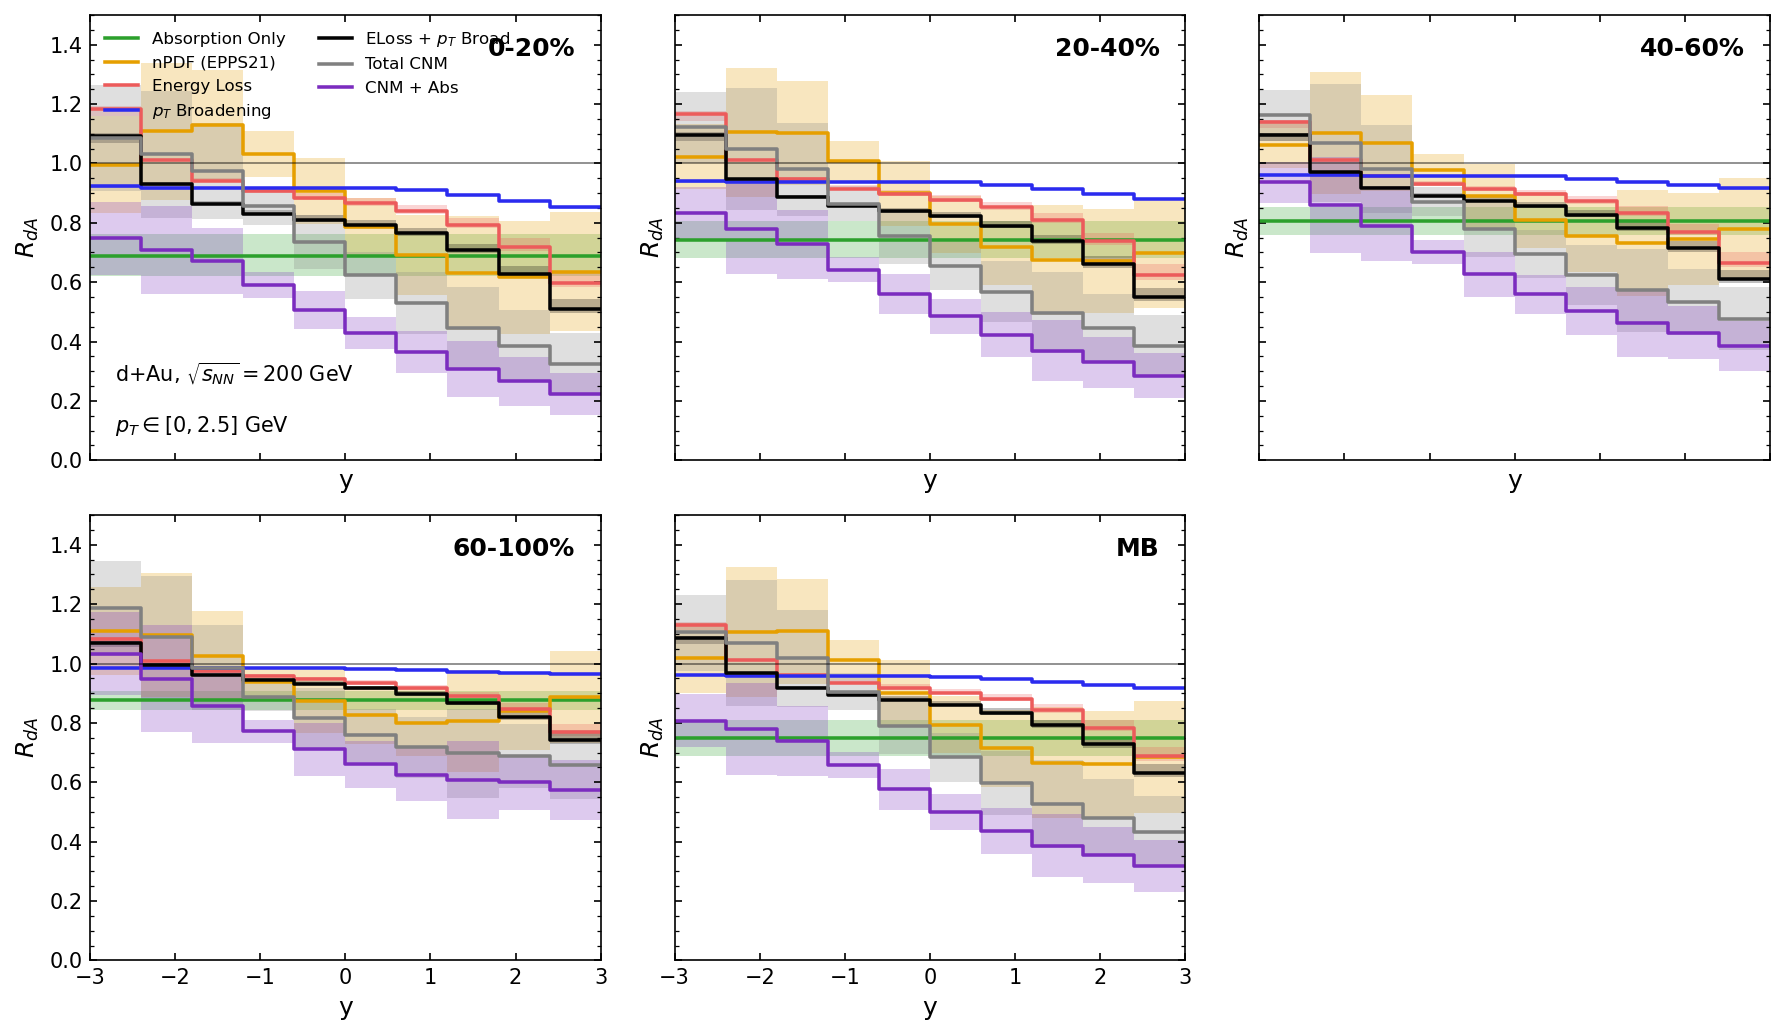

✓ Plot saved: RdA_vs_y_all_components.pdf


In [4]:
# 1. R_dA vs y (pT in [0,2.5] GeV)
y_edges = np.linspace(-3.0, 3.0, 11)

print("\nCalculating baseline CNM components (no absorption)...")
y_cent, labels, final_bands_y_baseline = cnm.cnm_vs_y(
    y_edges, pt_range_avg=(0.0, 2.5), components=components_base, include_mb=True
)

print("Calculating absorption CNM components (σ_abs = 4.2 mb)...")
_, _, final_bands_y_abs = cnm_abs.cnm_vs_y(
    y_edges, pt_range_avg=(0.0, 2.5), components=["cnm"], include_mb=True
)

abs_band_y = flat_band_from_green_map(y_cent, green_map)
final_bands_y = {comp: final_bands_y_baseline[comp] for comp in components_base}
final_bands_y["abs_only"] = abs_band_y
final_bands_y["cnm_abs"] = final_bands_y_abs["cnm"]

print(f"✓ Components calculated: {list(final_bands_y.keys())}")

tags_to_plot = labels + ["MB"]
n_pan = len(tags_to_plot)
n_cols = 3
n_rows = int(np.ceil(n_pan / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), dpi=DPI, sharex=True, sharey=True
)
axes = np.atleast_1d(axes).ravel()
note_y = "d+Au, $\\sqrt{s_{NN}} = 200$ GeV\n\n$p_T \\in [0,2.5]$ GeV"

for i, tag in enumerate(tags_to_plot):
    ax = axes[i]
    for comp in components_plot:
        plot_component_band(ax, y_cent, final_bands_y, comp, tag)
    apply_pub_style(ax, (-3.0, 3.0), (0.0, 1.5), "y", r"$R_{dA}$", tag=tag, note=note_y if i == 0 else None)
    if i == 0:
        handles = [plt.Line2D([], [], color=COLORS[c], lw=1.7, label=COMP_LABELS[c]) for c in components_plot]
        ax.legend(handles=handles, loc="upper left", fontsize=8, ncol=2, frameon=False)

for j in range(n_pan, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
if SAVE_PDF:
    plt.savefig(outdir / "RdA_vs_y_all_components.pdf", bbox_inches="tight")
plt.show()
print("✓ Plot saved: RdA_vs_y_all_components.pdf")

## 2. $R_{dA}$ vs $p_T$ in Rapidity Windows

  Computing vs pT in window -2.2<y<-1.2


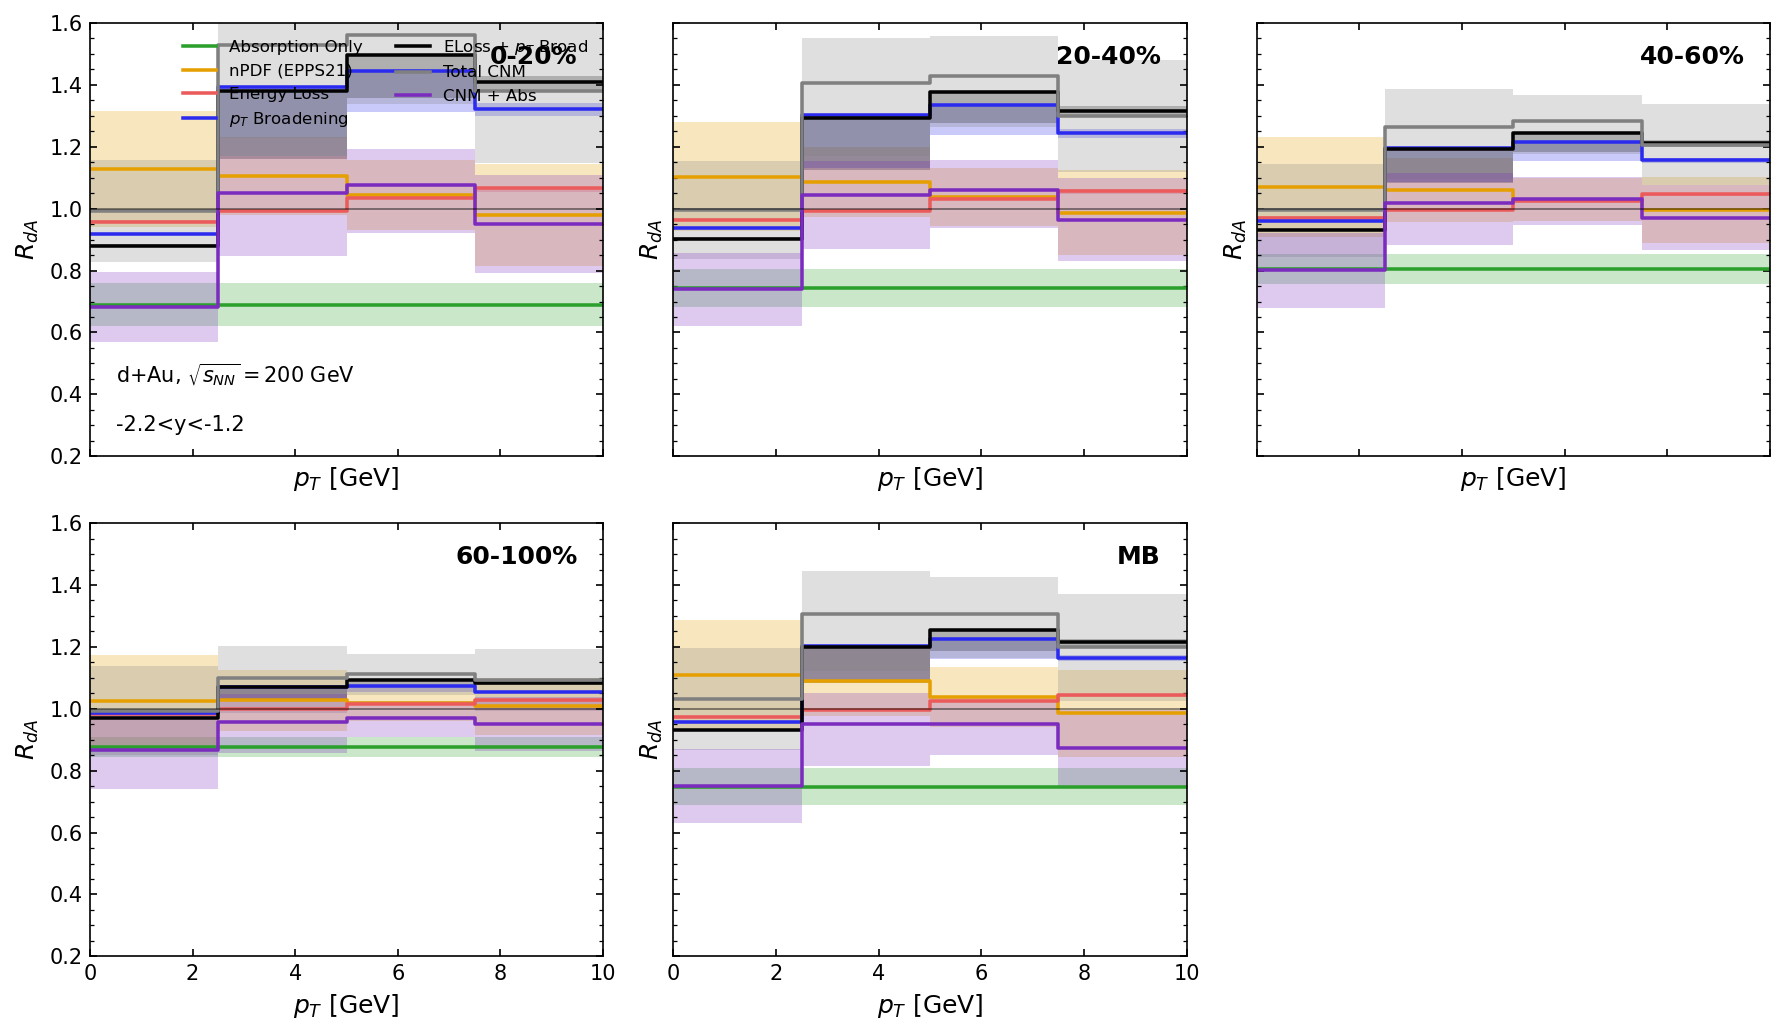

  Computing vs pT in window -0.35<y<0.35


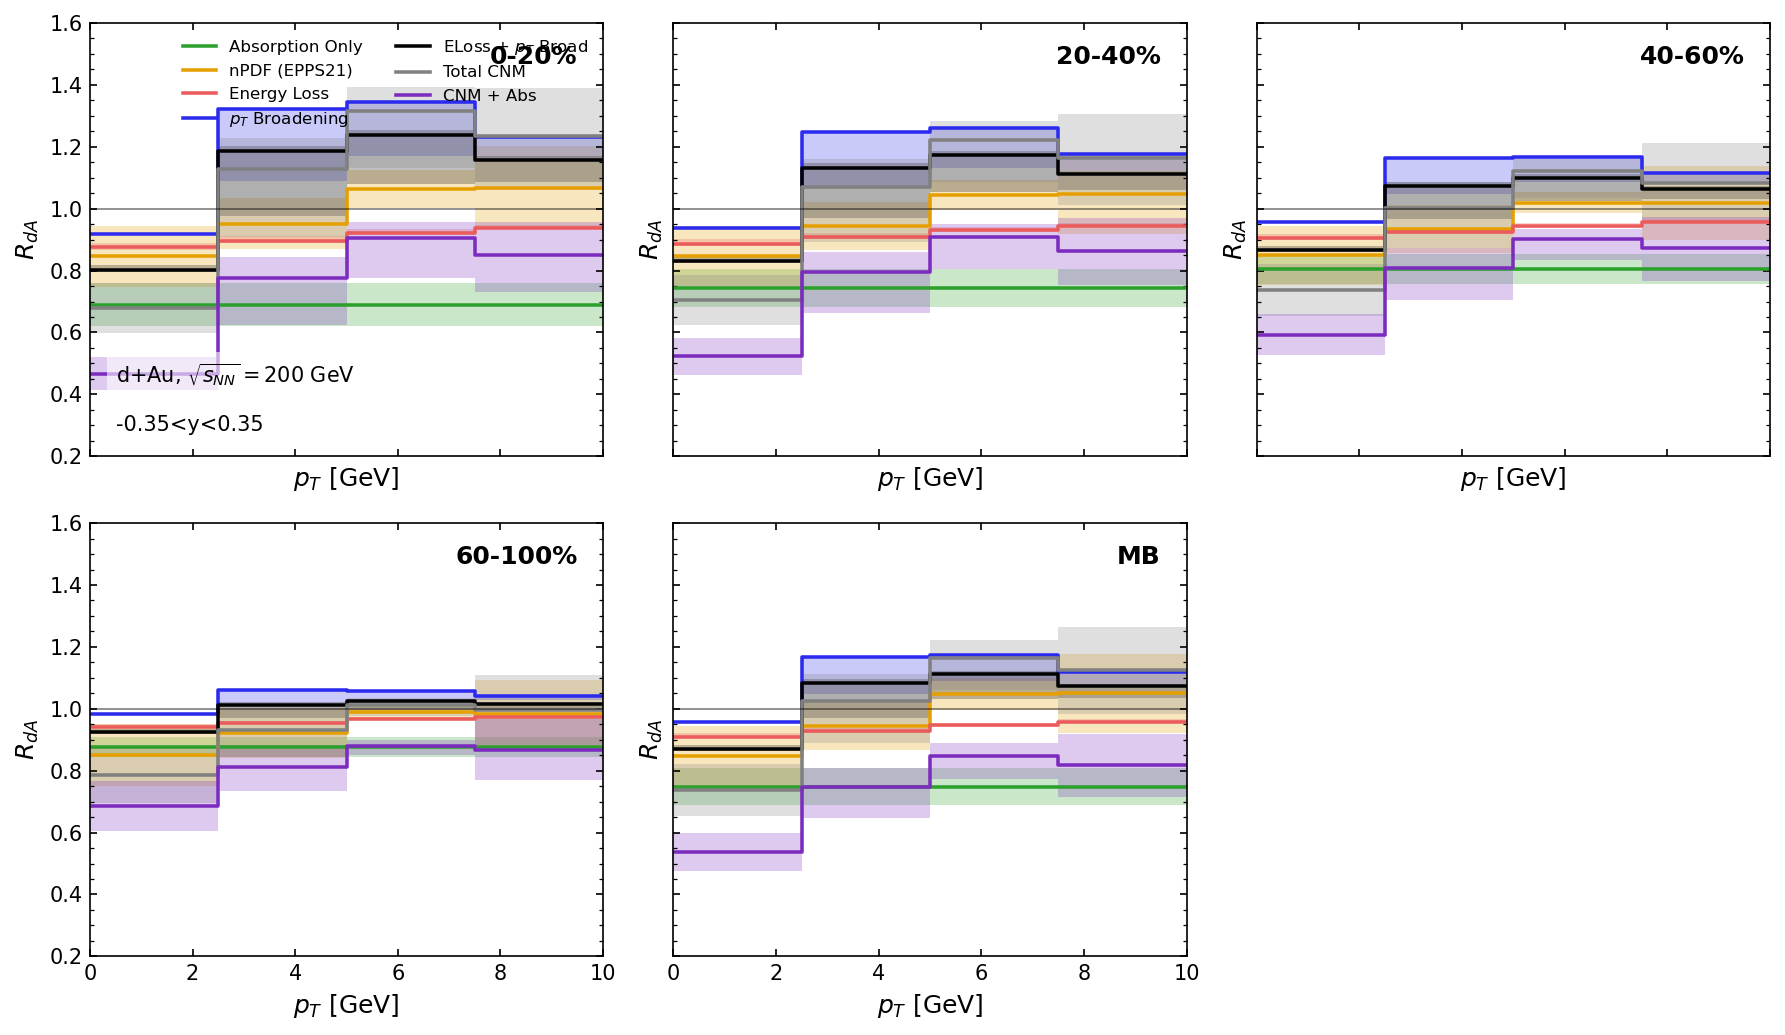

  Computing vs pT in window 1.2<y<2.2


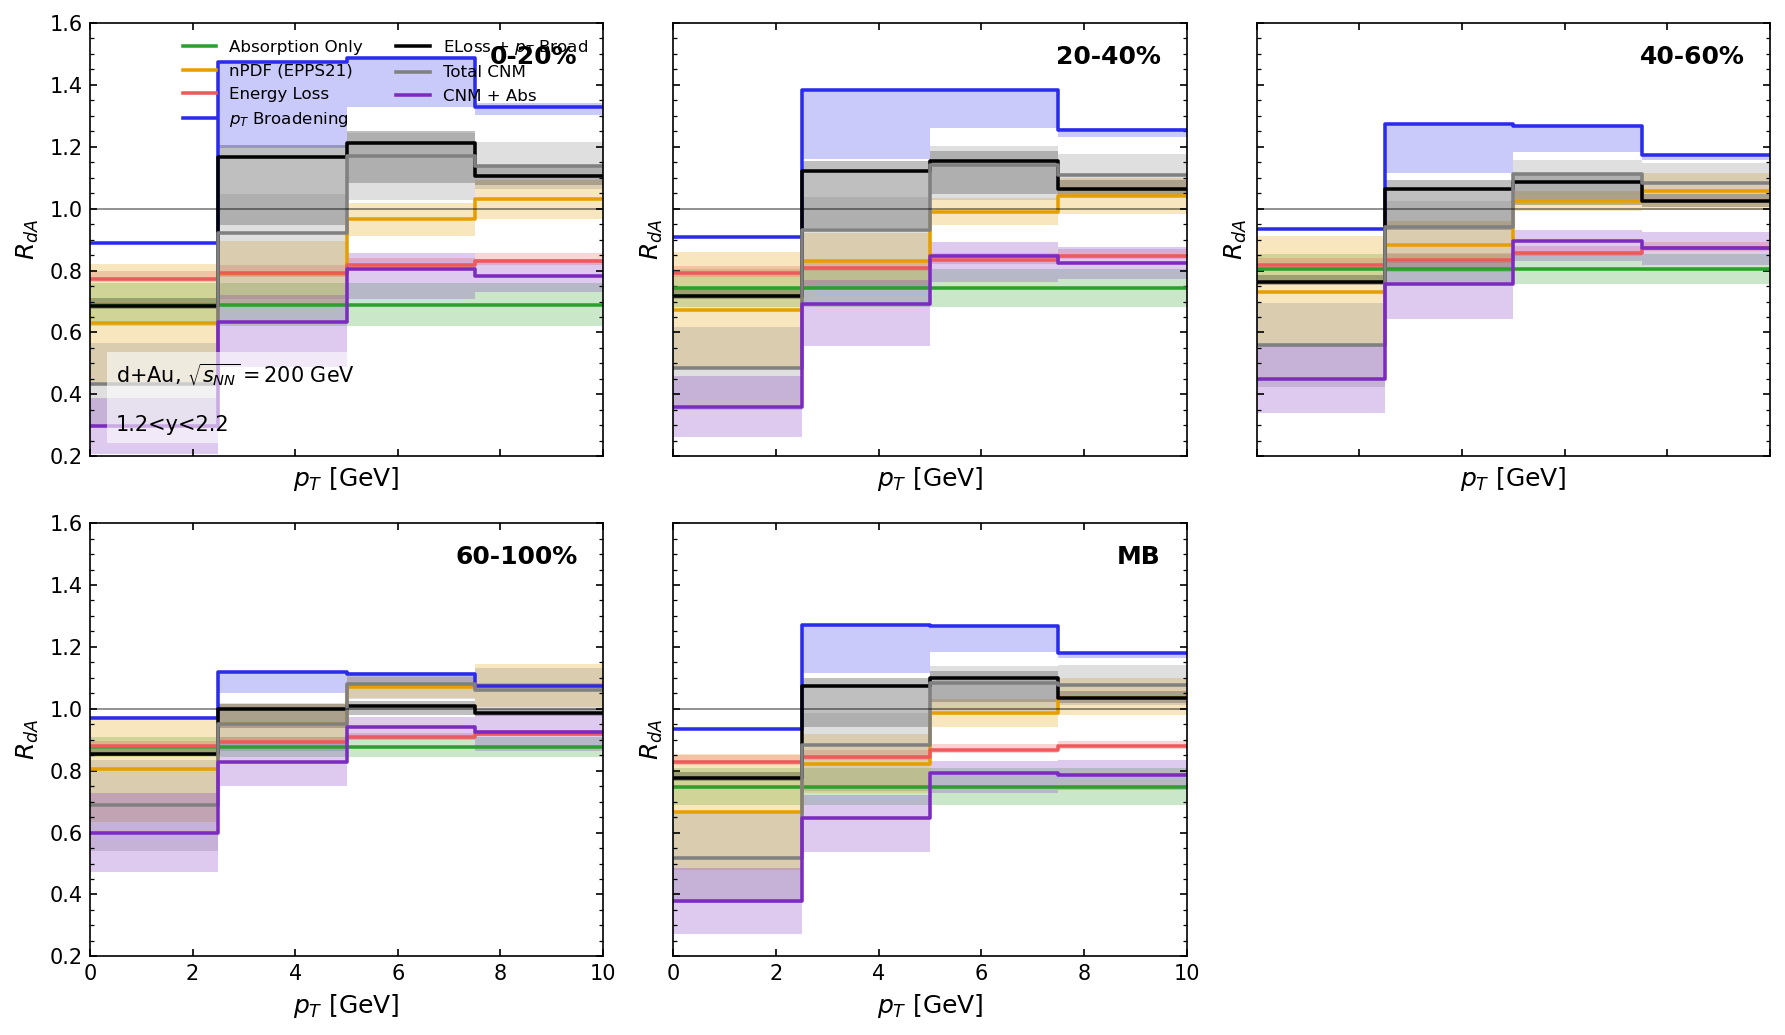

In [5]:
# 2. R_dA vs pT in rapidity windows (pT ∈ [0,10] GeV)
pT_edges = np.arange(0, 12.5, 2.5)

for y_window in Config.rapidity_windows:
    y0, y1 = y_window
    w_name = f"{y0}<y<{y1}"
    print(f"  Computing vs pT in window {w_name}")

    # Baseline CNM (no absorption)
    pT_cent, labels_pt, bands_pt_base = cnm.cnm_vs_pT(
        y_window, pT_edges, components=components_base, include_mb=True
    )

    # CNM with absorption (only need cnm component)
    _, _, bands_pt_abs = cnm_abs.cnm_vs_pT(
        y_window, pT_edges, components=["cnm"], include_mb=True
    )

    # Absorption-only flat band
    abs_band_pt = flat_band_from_green_map(pT_cent, green_map)

    # Merge bands
    bands_pt = {comp: bands_pt_base[comp] for comp in components_base}
    bands_pt["abs_only"] = abs_band_pt
    bands_pt["cnm_abs"] = bands_pt_abs["cnm"]

    tags_to_plot = labels_pt + ["MB"]
    n_pan = len(tags_to_plot)
    n_cols = 3
    n_rows = int(np.ceil(n_pan / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows),
        dpi=DPI, sharex=True, sharey=True
    )
    axes = np.atleast_1d(axes).ravel()
    note_pt = f"d+Au, $\\sqrt{{s_{{NN}}}} = 200$ GeV\n\n{w_name}"

    for i, tag in enumerate(tags_to_plot):
        ax = axes[i]
        for comp in components_plot:
            plot_component_band(ax, pT_cent, bands_pt, comp, tag)
        apply_pub_style(ax, (0, 10), (0.2, 1.6), r"$p_T$ [GeV]", r"$R_{dA}$",
                        tag=tag, note=note_pt if i == 0 else None)
        if i == 0:
            handles = [plt.Line2D([], [], color=COLORS[c], lw=1.7, label=COMP_LABELS[c])
                       for c in components_plot]
            ax.legend(handles=handles, loc="upper right", fontsize=8, ncol=2, frameon=False)

    for k in range(n_pan, len(axes)):
        fig.delaxes(axes[k])

    fig.tight_layout()
    safe_w = w_name.replace("<", "").replace(">", "").replace("/", "_")
    if SAVE_PDF:
        fig.savefig(outdir / f"RdAu_vs_pT_all_components_{safe_w}_200GeV.pdf", bbox_inches="tight")
    plt.show()

  Computing vs pT (MASTER GRID) with absorption bands...
  window -2.2<y<-1.2
  window -0.35<y<0.35
  window 1.2<y<2.2


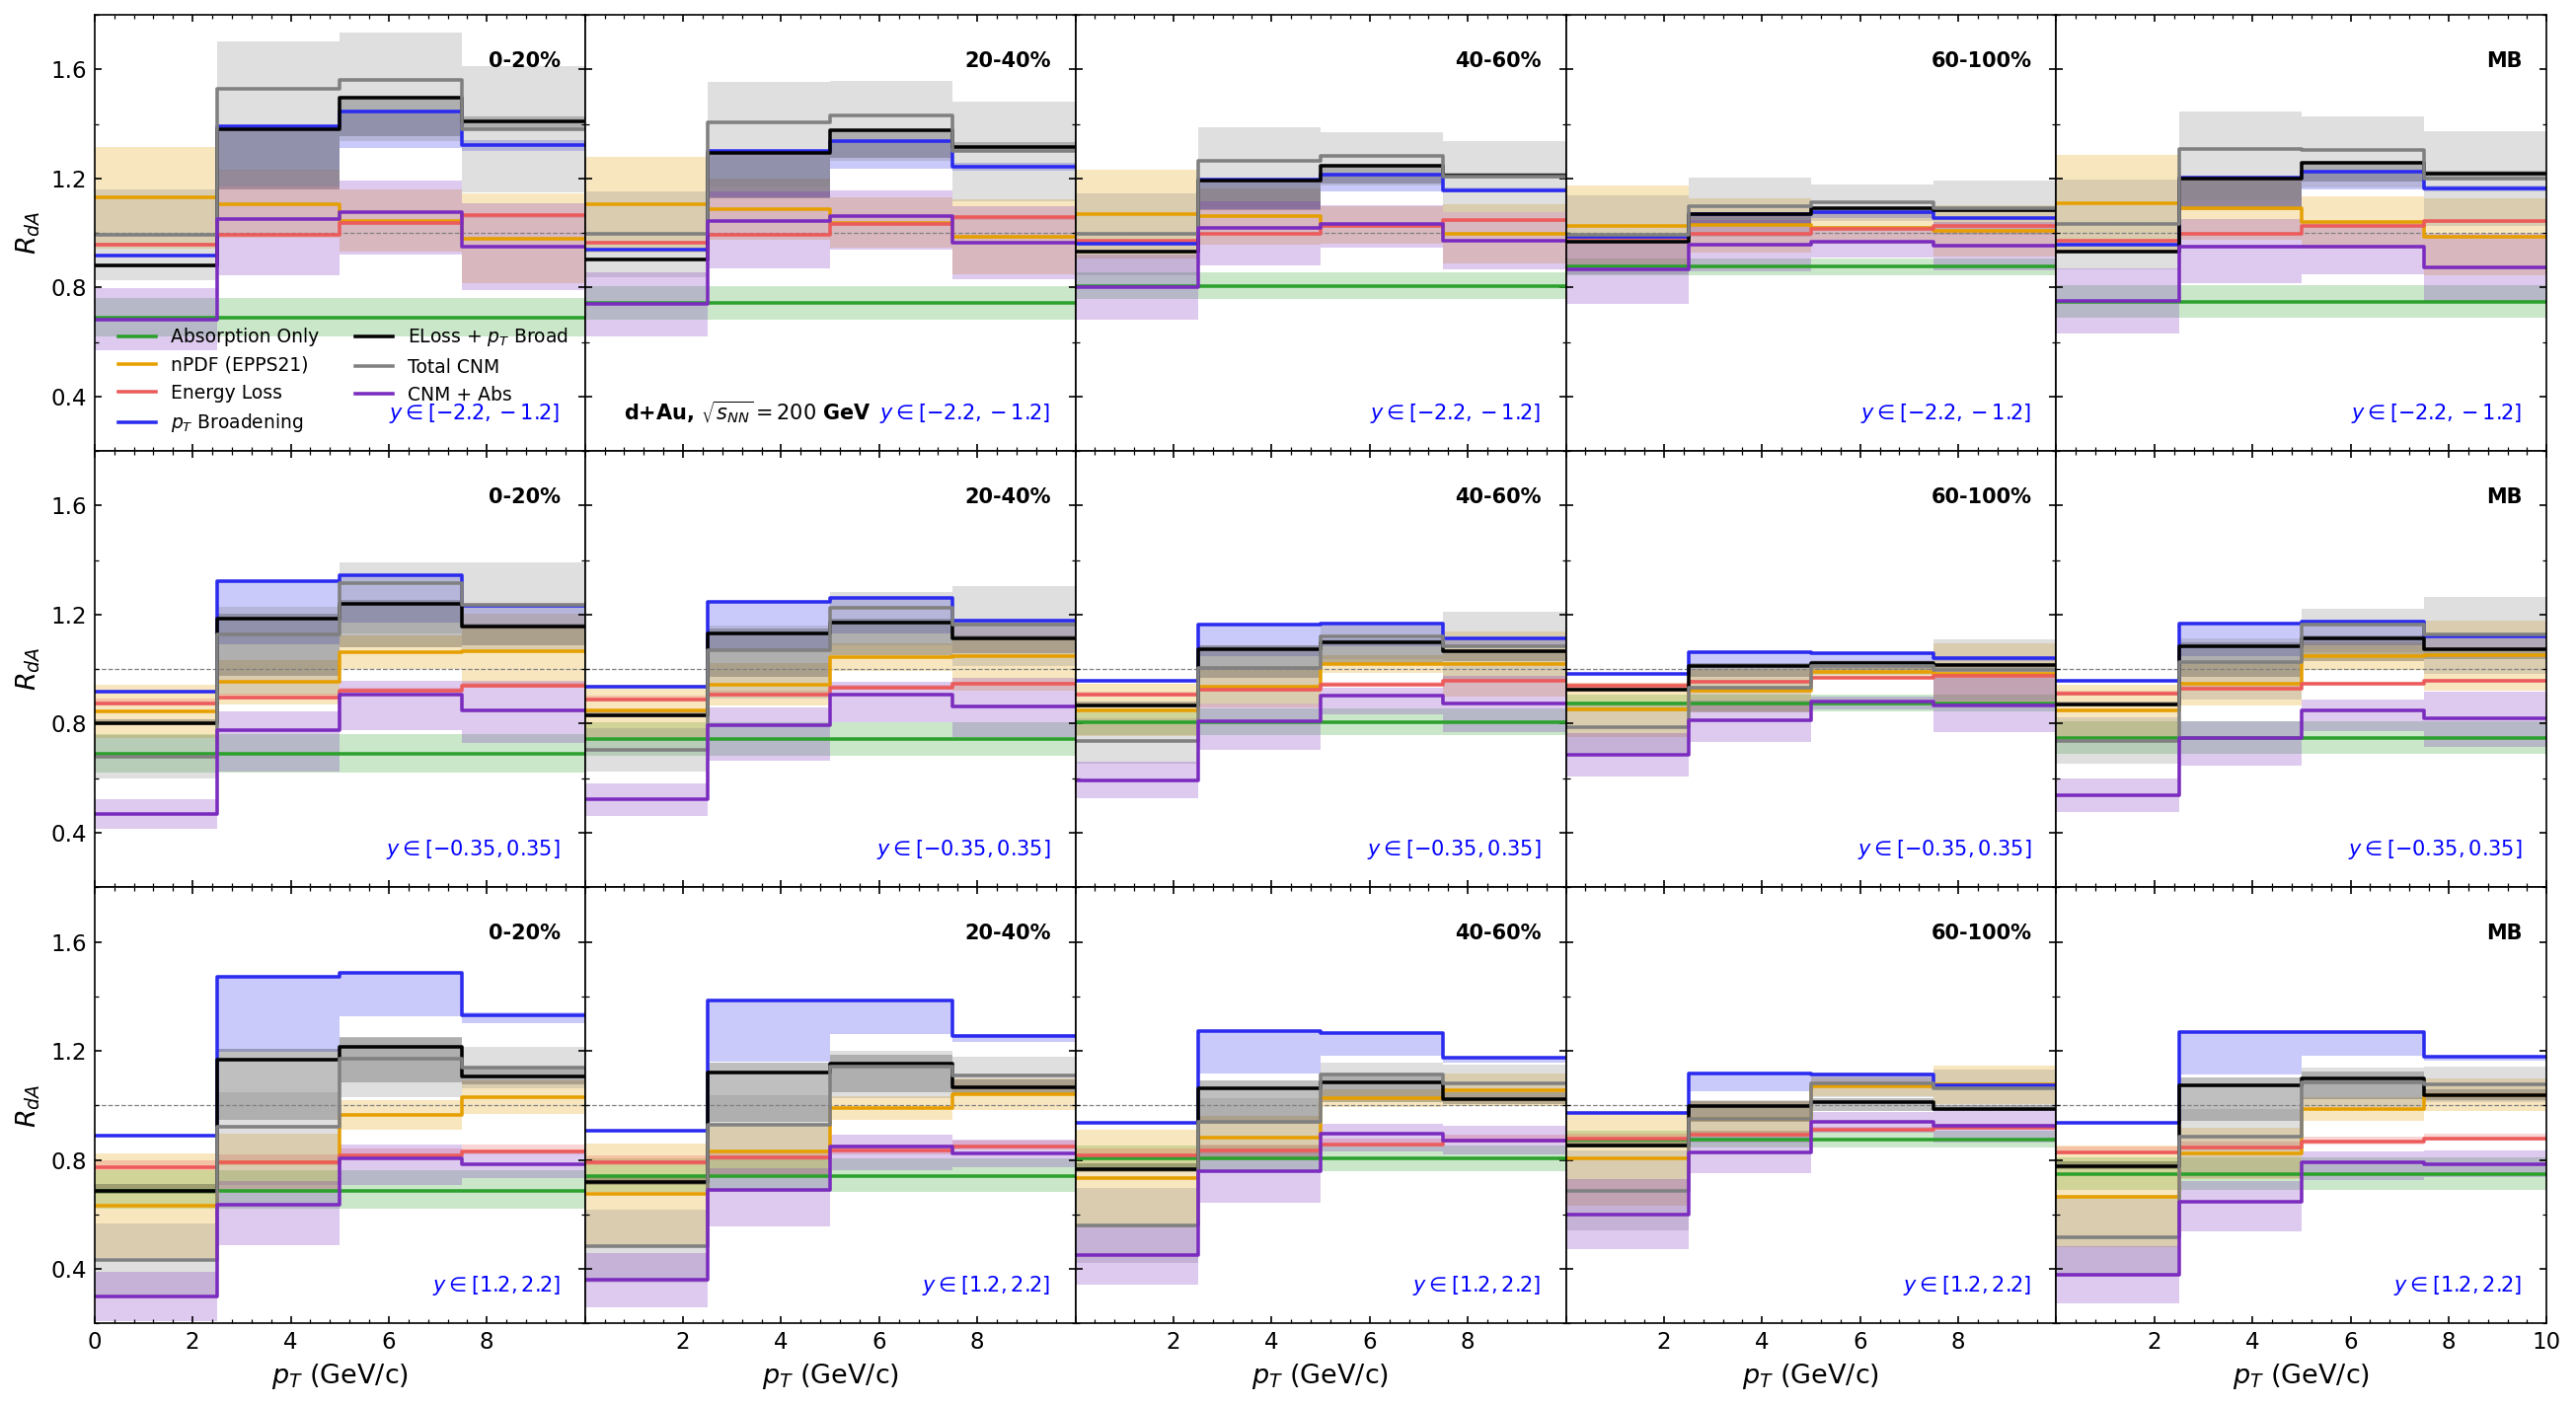

In [6]:
import matplotlib.ticker as ticker

print("  Computing vs pT (MASTER GRID) with absorption bands...")

# components to draw in the grid
components_plot = ['abs_only', 'npdf', 'eloss', 'broad', 'eloss_broad', 'cnm', 'cnm_abs']

y_windows = list(Config.rapidity_windows)
nrows = len(y_windows)

# First window to size the grid
y0, y1 = y_windows[0]
pT_edges = np.arange(0, 12.5, 2.5)

# Baseline CNM (no absorption)
pT_cent0, labels_pt0, bands_pt_base0 = cnm.cnm_vs_pT(
    (y0, y1), pT_edges, components=['npdf', 'eloss', 'broad', 'eloss_broad', 'cnm'], include_mb=True
)
# Absorption CNM (only need cnm)
_, _, bands_pt_abs0 = cnm_abs.cnm_vs_pT(
    (y0, y1), pT_edges, components=['cnm'], include_mb=True
)
abs_band_pt0 = flat_band_from_green_map(pT_cent0, green_map)

# Merge to master dict for sizing
bands_pt0 = {**bands_pt_base0}
bands_pt0['abs_only'] = abs_band_pt0
bands_pt0['cnm_abs'] = bands_pt_abs0['cnm']

cent_tags = labels_pt0 + ["MB"]
ncols = len(cent_tags)

fig, axs = plt.subplots(
    nrows, ncols,
    figsize=(3.5 * ncols, 3.2 * nrows),
    dpi=DPI,
    sharex=True, sharey=True,
    gridspec_kw={"wspace": 0.0, "hspace": 0.0}
)
axs = np.atleast_2d(axs)

note_row, note_col = 0, (1 if ncols > 1 else 0)

for irow, y_window in enumerate(y_windows):
    y0, y1 = y_window
    w_name = f"{y0}<y<{y1}"
    print(f"  window {w_name}")

    pT_edges = np.arange(0, 12.5, 2.5)

    # Baseline
    pT_cent, labels_pt, bands_pt_base = cnm.cnm_vs_pT(
        y_window, pT_edges, components=['npdf', 'eloss', 'broad', 'eloss_broad', 'cnm'], include_mb=True
    )
    # Absorption
    _, _, bands_pt_abs = cnm_abs.cnm_vs_pT(
        y_window, pT_edges, components=['cnm'], include_mb=True
    )
    abs_band_pt = flat_band_from_green_map(pT_cent, green_map)

    # Merge
    bands_pt = {**bands_pt_base}
    bands_pt['abs_only'] = abs_band_pt
    bands_pt['cnm_abs'] = bands_pt_abs['cnm']

    for jcol, tag in enumerate(cent_tags):
        ax = axs[irow, jcol]

        for comp in components_plot:
            plot_component_band(ax, pT_cent, bands_pt, comp, tag, step=True)

        ax.axhline(1.0, color="gray", lw=0.6, ls="--", zorder=1)
        ax.set_xlim(0, 10)
        ax.set_ylim(0.2, 1.8)
        ax.tick_params(direction="in", which="both", top=True, right=True, labelsize=11)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

        ax.text(0.95, 0.06, rf"$y \in [{y0}, {y1}]$",
                transform=ax.transAxes, ha="right", va="bottom",
                fontsize=10, color="blue", fontweight="bold")

        ax.text(0.95, 0.88, "MB" if tag == "MB" else tag,
                transform=ax.transAxes, ha="right", fontweight="bold", fontsize=10)

        if irow == nrows - 1:
            ax.set_xlabel(r"$p_T$ (GeV/c)", fontsize=13)
        if jcol == 0:
            ax.set_ylabel(r"$R_{dA}$", fontsize=13)

        if (irow == note_row) and (jcol == note_col):
            ax.text(0.08, 0.06, r"d+Au, $\sqrt{s_{NN}}=200$ GeV",
                    transform=ax.transAxes, ha="left", va="bottom",
                    fontsize=10, fontweight="bold")

        if irow == nrows - 1:
            ticks = ax.xaxis.get_major_ticks()
            if jcol > 0 and ticks:
                ticks[0].label1.set_visible(False)
            if jcol < ncols - 1 and ticks:
                ticks[-1].label1.set_visible(False)

# Legend on the first panel
handles = [plt.Line2D([], [], color=COLORS[c], lw=1.7, label=COMP_LABELS[c]) for c in components_plot]
axs[0, 0].legend(handles=handles, loc="lower right", fontsize=9, frameon=False, ncol=2)

fig.tight_layout()
if SAVE_PDF:
    fig.savefig(outdir / "RdAu_vs_pT_MASTERGRID_200GeV.pdf", bbox_inches="tight")
plt.show()

## 3. $R_{dA}$ vs Centrality

  Computing vs Centrality (0-2.5 GeV)...


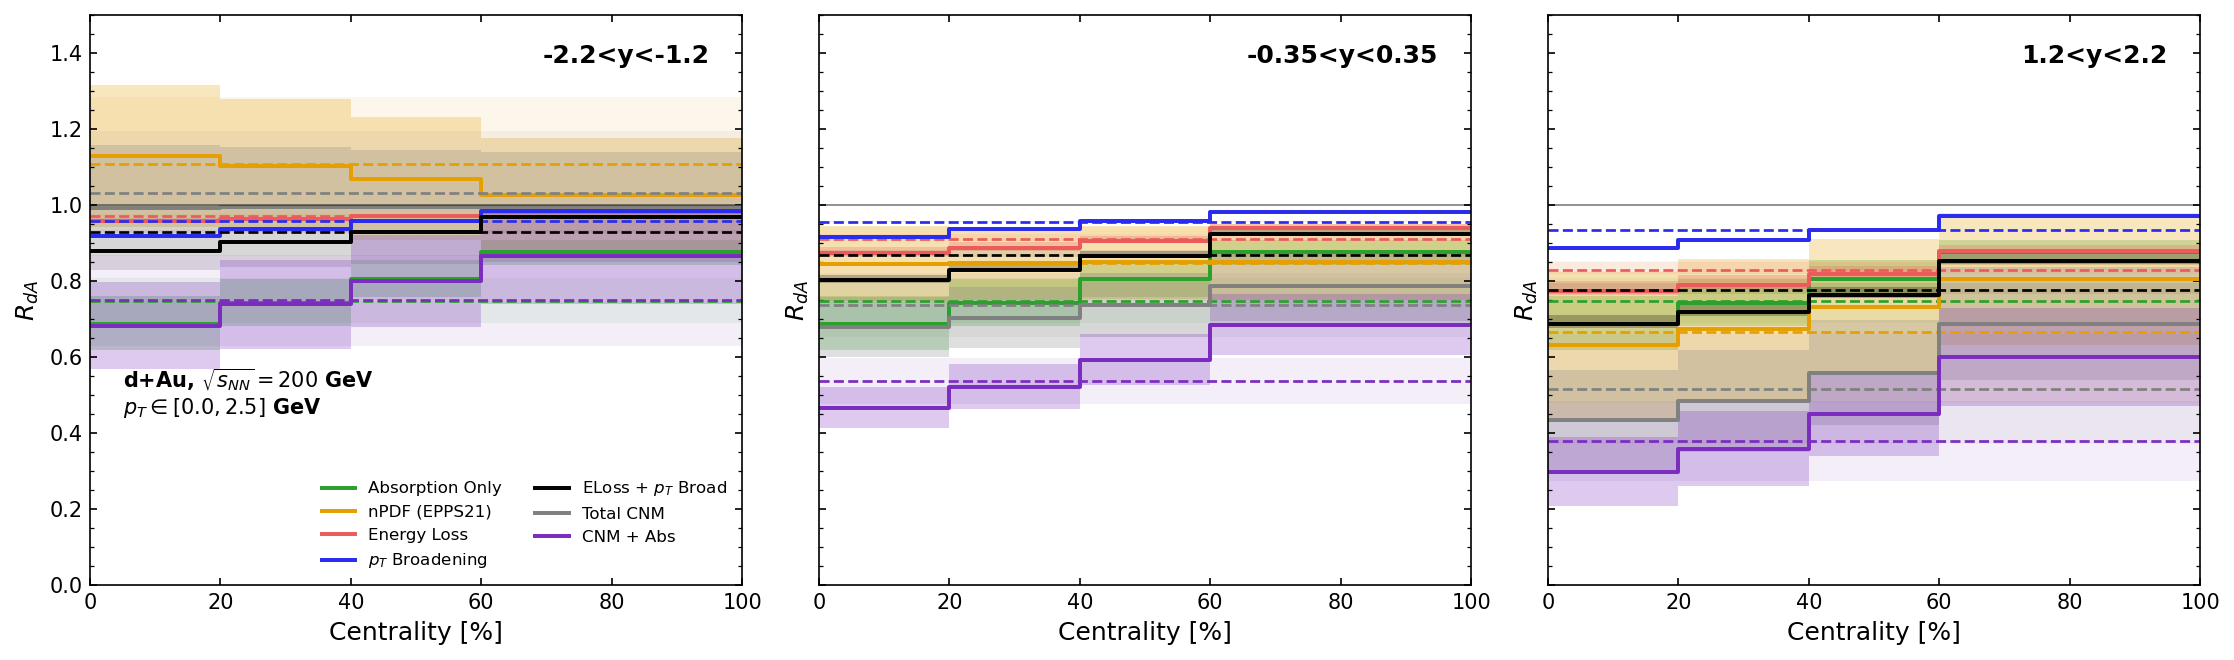

In [7]:
# 3. R_dA vs Centrality (pT in [0,2.5] GeV)
print("  Computing vs Centrality (0-2.5 GeV)...")
from matplotlib.lines import Line2D

cent_bins = Config.cent_bins
x_edges = np.array([cent_bins[0][0]] + [b for (_, b) in cent_bins], dtype=float)

def cent_step(yvals):
    yvals = np.asarray(yvals, float)
    return np.r_[yvals, yvals[-1]]

pt_min, pt_max = (0.0, 2.5)

fig, axes = plt.subplots(1, len(Config.rapidity_windows), figsize=(15, 4.5), dpi=DPI, sharey=True)
axes = np.atleast_1d(axes)

for ax, y_window in zip(axes, Config.rapidity_windows):
    y0, y1 = y_window
    base = cnm.cnm_vs_centrality((y0, y1), pt_range_avg=(pt_min, pt_max))
    with_abs = cnm_abs.cnm_vs_centrality((y0, y1), pt_range_avg=(pt_min, pt_max))

    tags = [f"{int(a)}-{int(b)}%" for (a,b) in cent_bins]
    Rc = [green_map[t][0] for t in tags]
    Rlo= [green_map[t][1] for t in tags]
    Rhi= [green_map[t][2] for t in tags]
    mb_c, mb_lo, mb_hi = green_map['MB']
    abs_only = (np.asarray(Rc,float), np.asarray(Rlo,float), np.asarray(Rhi,float), float(mb_c), float(mb_lo), float(mb_hi))

    final = {comp: base[comp] for comp in components_base}
    final['abs_only'] = abs_only
    final['cnm_abs']  = with_abs['cnm']

    for comp in components_plot:
        vc, vl, vh, mbc, mbl, mbh = final[comp]
        color = COLORS[comp]
        label = COMP_LABELS[comp]
        y_c  = cent_step(vc)
        y_lo = cent_step(vl)
        y_hi = cent_step(vh)
        ax.step(x_edges, y_c, where="post", color=color, lw=1.9, label=label if ax is axes[0] else None)
        ax.fill_between(x_edges, y_lo, y_hi, step="post", color=color, alpha=ALPHA_BAND, lw=0)
        ax.hlines(mbc, 0.0, 100.0, colors=color, linestyles="--", linewidth=1.3)
        ax.fill_between([0,100],[mbl,mbl],[mbh,mbh], color=color, alpha=0.08, lw=0)

    apply_pub_style(ax, (0,100), (0.0,1.5), 'Centrality [%]', r'$R_{dA}$', tag=f"{y0}<y<{y1}")
    if ax is axes[0]:
        handles = [Line2D([],[], color=COLORS[c], lw=1.9, label=COMP_LABELS[c]) for c in components_plot]
        ax.legend(handles=handles, loc='lower right', fontsize=8, frameon=False, ncol=2)
        ax.text(0.05,0.30, r"d+Au, $\sqrt{s_{NN}}=200$ GeV" + "\n" + rf"$p_T\in[{pt_min},{pt_max}]$ GeV", transform=ax.transAxes, fontsize=10, fontweight='bold')

fig.tight_layout()
plt.savefig(outdir / 'RdA_vs_centrality_all_components_0to2p5GeV.pdf', bbox_inches='tight') if SAVE_PDF else None
plt.show()


  Computing vs Centrality (0-5 GeV)...


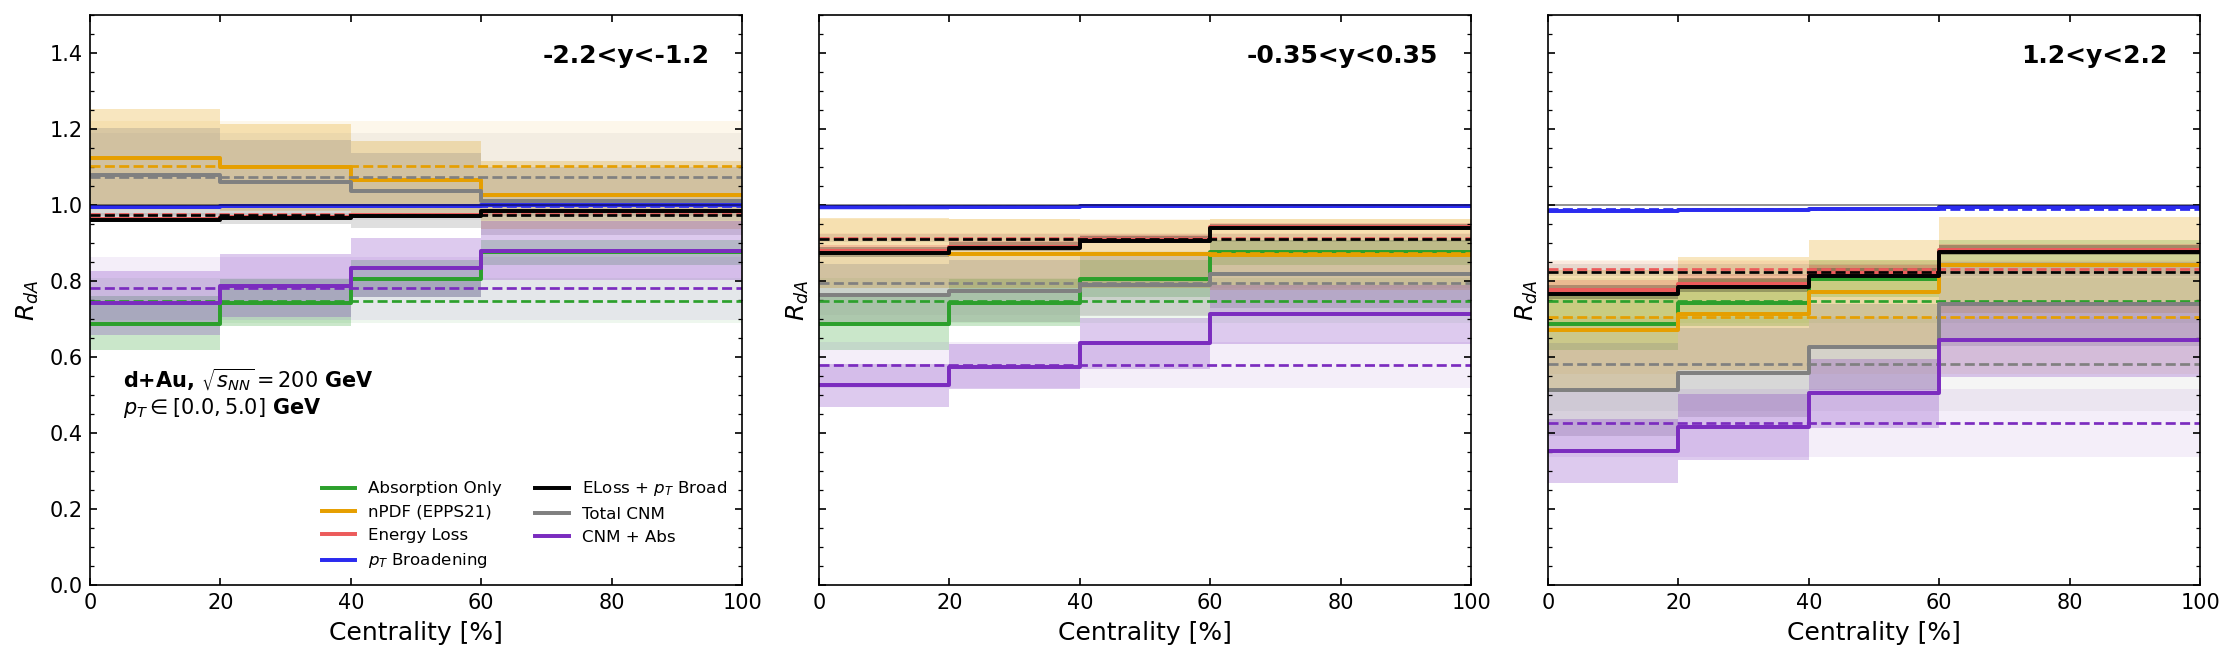

In [8]:
# 3. R_dA vs Centrality (pT in [0,5] GeV)
print("  Computing vs Centrality (0-5 GeV)...")
from matplotlib.lines import Line2D

cent_bins = Config.cent_bins
x_edges = np.array([cent_bins[0][0]] + [b for (_, b) in cent_bins], dtype=float)

def cent_step(yvals):
    yvals = np.asarray(yvals, float)
    return np.r_[yvals, yvals[-1]]

pt_min, pt_max = (0.0, 5.0)

fig, axes = plt.subplots(1, len(Config.rapidity_windows), figsize=(15, 4.5), dpi=DPI, sharey=True)
axes = np.atleast_1d(axes)

for ax, y_window in zip(axes, Config.rapidity_windows):
    y0, y1 = y_window
    base = cnm.cnm_vs_centrality((y0, y1), pt_range_avg=(pt_min, pt_max))
    with_abs = cnm_abs.cnm_vs_centrality((y0, y1), pt_range_avg=(pt_min, pt_max))

    tags = [f"{int(a)}-{int(b)}%" for (a,b) in cent_bins]
    Rc = [green_map[t][0] for t in tags]
    Rlo= [green_map[t][1] for t in tags]
    Rhi= [green_map[t][2] for t in tags]
    mb_c, mb_lo, mb_hi = green_map['MB']
    abs_only = (np.asarray(Rc,float), np.asarray(Rlo,float), np.asarray(Rhi,float), float(mb_c), float(mb_lo), float(mb_hi))

    final = {comp: base[comp] for comp in components_base}
    final['abs_only'] = abs_only
    final['cnm_abs']  = with_abs['cnm']

    for comp in components_plot:
        vc, vl, vh, mbc, mbl, mbh = final[comp]
        color = COLORS[comp]
        label = COMP_LABELS[comp]
        y_c  = cent_step(vc)
        y_lo = cent_step(vl)
        y_hi = cent_step(vh)
        ax.step(x_edges, y_c, where="post", color=color, lw=1.9, label=label if ax is axes[0] else None)
        ax.fill_between(x_edges, y_lo, y_hi, step="post", color=color, alpha=ALPHA_BAND, lw=0)
        ax.hlines(mbc, 0.0, 100.0, colors=color, linestyles="--", linewidth=1.3)
        ax.fill_between([0,100],[mbl,mbl],[mbh,mbh], color=color, alpha=0.08, lw=0)

    apply_pub_style(ax, (0,100), (0.0,1.5), 'Centrality [%]', r'$R_{dA}$', tag=f"{y0}<y<{y1}")
    if ax is axes[0]:
        handles = [Line2D([],[], color=COLORS[c], lw=1.9, label=COMP_LABELS[c]) for c in components_plot]
        ax.legend(handles=handles, loc='lower right', fontsize=8, frameon=False, ncol=2)
        ax.text(0.05,0.30, r"d+Au, $\sqrt{s_{NN}}=200$ GeV" + "\n" + rf"$p_T\in[{pt_min},{pt_max}]$ GeV", transform=ax.transAxes, fontsize=10, fontweight='bold')

fig.tight_layout()
plt.savefig(outdir / 'RdA_vs_centrality_all_components_0to5GeV.pdf', bbox_inches='tight') if SAVE_PDF else None
plt.show()
